<a href="https://colab.research.google.com/github/VISHAL-1-3/Diabetes-Prediction/blob/main/Diabetes_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

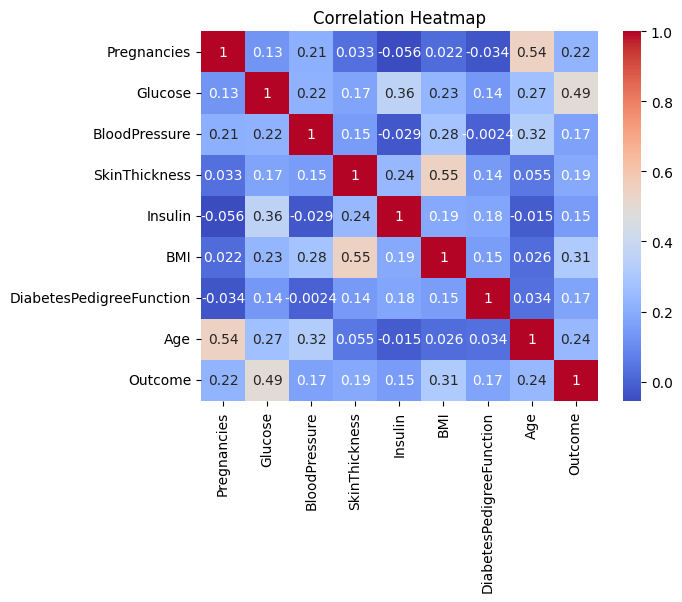

Best Parameters: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200}
Cross-validated ROC-AUC: 0.8383158630328442

Accuracy: 0.7597402597402597
ROC-AUC: 0.8196296296296297

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       100
           1       0.63      0.78      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154



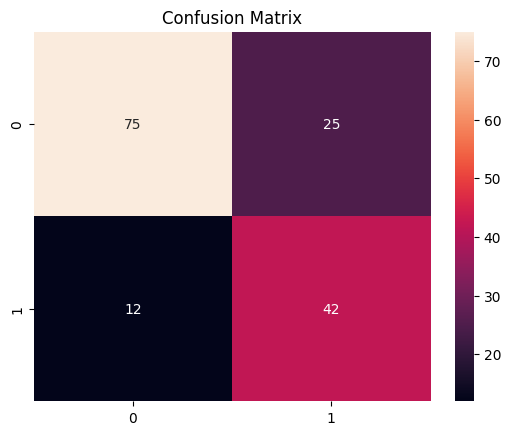

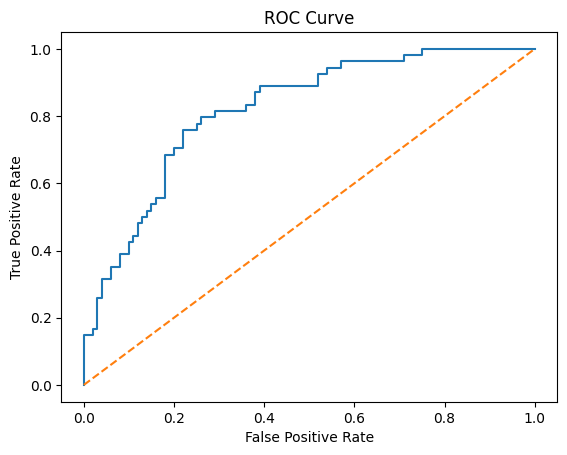

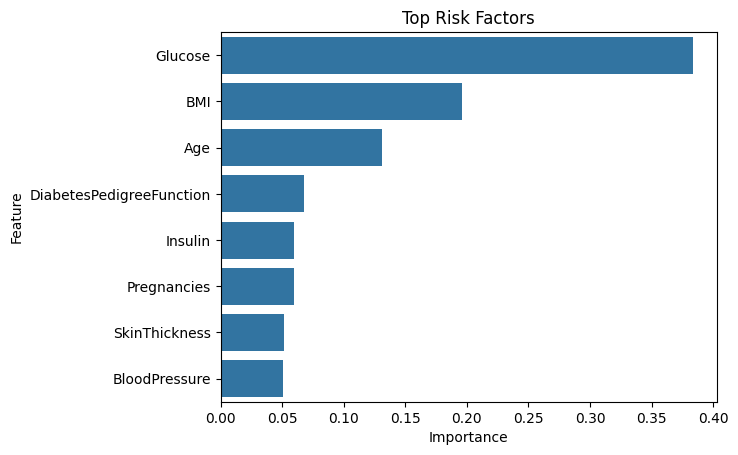

                    Feature  Importance
1                   Glucose    0.383623
5                       BMI    0.195720
7                       Age    0.131533
6  DiabetesPedigreeFunction    0.067720
4                   Insulin    0.059624
0               Pregnancies    0.059361
3             SkinThickness    0.051435
2             BloodPressure    0.050985

Risk Segment Distribution:
Risk_Category
Low Risk       55
High Risk      50
Medium Risk    49
Name: count, dtype: int64

High Risk Patients: 50

Estimated Campaign Cost: 5000
Estimated Potential Benefit: 25000
Net Gain: 20000


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load dataset
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)

# -----------------------------
# DATA CLEANING
# -----------------------------
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

# -----------------------------
# EDA
# -----------------------------
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# FEATURE & TARGET
# -----------------------------
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# MODEL + HYPERPARAMETER TUNING
# -----------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    class_weight={0:1, 1:2},   # give more weight to diabetic class
    random_state=42
)

grid = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# -----------------------------
# CROSS VALIDATION SCORE
# -----------------------------
cv_score = cross_val_score(best_model, X_scaled, y, cv=5, scoring='roc_auc')
print("Cross-validated ROC-AUC:", cv_score.mean())

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# -----------------------------
# METRICS
# -----------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# ROC CURVE
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Top Risk Factors")
plt.show()

print(importance)

# -----------------------------
# 🔥 ZS-STYLE: RISK SEGMENTATION
# -----------------------------
df_test = pd.DataFrame(X_test, columns=X.columns)
df_test['Actual'] = y_test.values
df_test['Risk_Probability'] = y_prob

def risk_segment(p):
    if p >= 0.6:   # instead of 0.7
        return "High Risk"
    elif p >= 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df_test['Risk_Category'] = df_test['Risk_Probability'].apply(risk_segment)

print("\nRisk Segment Distribution:")
print(df_test['Risk_Category'].value_counts())

# -----------------------------
# 📊 BUSINESS INSIGHT SIMULATION
# -----------------------------
high_risk = df_test[df_test['Risk_Category'] == "High Risk"]

print("\nHigh Risk Patients:", len(high_risk))

# Assume campaign cost & benefit
cost_per_patient = 100
benefit_per_patient = 500

total_cost = len(high_risk) * cost_per_patient
potential_benefit = len(high_risk) * benefit_per_patient

print("\nEstimated Campaign Cost:", total_cost)
print("Estimated Potential Benefit:", potential_benefit)
print("Net Gain:", potential_benefit - total_cost)

